# Exercise 5 — Noise budget, cubes and the detector

*Covers notebooks 05–06. Difficulty: ★★★★☆*

Target: a SN Ia at $z=1.3$ at maximum. SNR per resolution element, rest-frame 4000–7000 Å.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

In [2]:
import warnings
warnings.filterwarnings("ignore", message="failed to parse")

snia = slicersim.LazuliSupernova(redshift=1.3)
snr_range = dict(lbda_range=[4000, 7000], frame="rest")
_ = snia.setup_to_snr(10, **snr_range)
print(snia.get_readout_config(), f"{snia.get_exposure_time()/3600:.2f} h")

{'nmd': (64, 8, 0), 'nramps': 7} 2.82 h


### 5.1 — What limits the observation?

What fraction of the variance comes from each source in the rest-frame 4000–7000 Å range?
Group them in *detector* (`dark`, `roic_glow`, `thermal_dark`, `ron`) and *photon* noise
(`pointsource`, `background`, `host`, `thermal`).

*Hint: `snia.simulation.get_band_variance_contribution(**snr_range)`.*

In [3]:
budget = snia.simulation.get_band_variance_contribution(**snr_range)
detector = ["dark", "roic_glow", "thermal_dark", "ron"]
photon = ["pointsource", "background", "host", "thermal"]
for source in detector + photon:
    print(f"{source:12s} {budget[f'frac_{source}']:.1%}")
print(f"detector: {sum(budget[f'frac_{s}'] for s in detector):.0%}, "
      f"photon: {sum(budget[f'frac_{s}'] for s in photon):.0%}")

dark         37.1%
roic_glow    14.0%
thermal_dark 1.0%
ron          25.7%
pointsource  17.3%
background   5.0%
host         0.0%
thermal      0.4%
detector: 78%, photon: 23%


### 5.2 — A detector requirement study

How does the exposure time needed for SNR=10 change with the readout noise (4 to 20 e-/frame)?
And with the dark current (0.001 to 0.03 e-/s/pixel)? Plot both, relative to the nominal
exposure time. Which parameter matters most around its nominal value?

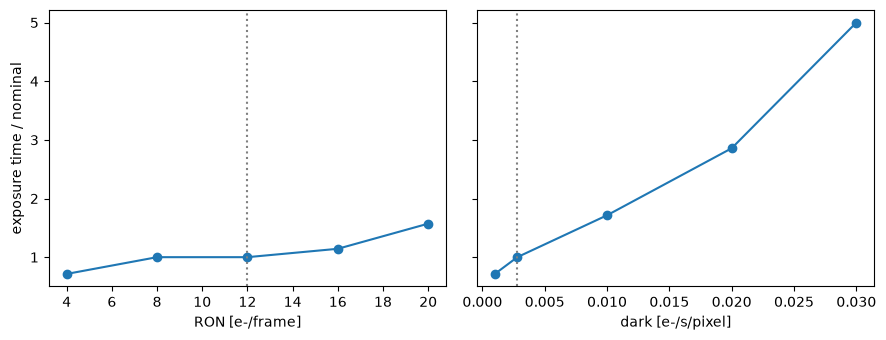

In [4]:
nominal = snia.get_properties(["ron", "dark"])
_ = snia.setup_to_snr(10, **snr_range)
exptime_nominal = snia.get_exposure_time()

def exptime_vs(parameter, values):
    exptimes = []
    for value in values:
        snia.change_properties(**{parameter: value})
        _ = snia.setup_to_snr(10, **snr_range)
        exptimes.append(snia.get_exposure_time() / exptime_nominal)
    snia.change_properties(**{parameter: nominal[parameter]})
    return exptimes

rons, darks = [4, 8, 12, 16, 20], [0.001, 0.0028, 0.01, 0.02, 0.03]
fig, (ax, ax_dark) = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
ax.plot(rons, exptime_vs("ron", rons), "o-")
ax.axvline(nominal["ron"], color="0.5", ls=":")
ax.set(xlabel="RON [e-/frame]", ylabel="exposure time / nominal")
ax_dark.plot(darks, exptime_vs("dark", darks), "o-")
ax_dark.axvline(nominal["dark"], color="0.5", ls=":")
ax_dark.set(xlabel="dark [e-/s/pixel]")
fig.tight_layout()
_ = snia.setup_to_snr(10, **snr_range)

### 5.3 — Aperture extraction from the cube

`get_spectrum()` assumes an optimal extraction. Do your own aperture extraction:

1. get the target-only signal cube (`switch_off=["background", "thermal"]`) and the full variance
   cube;
2. keep the wavelengths of the rest-frame 4000–7000 Å range and sum signal and variance within a
   circular aperture of radius $r$ around the SN;
3. plot the SNR as a function of $r$ (1 to 8 spaxels). What is the optimal radius?

*Hint: a spaxel is 1 slice × 2 pixels along the slice. The cube axes are
`(wavelength, slice, pixel along slice)`.*

optimal radius: 1.5 spaxels


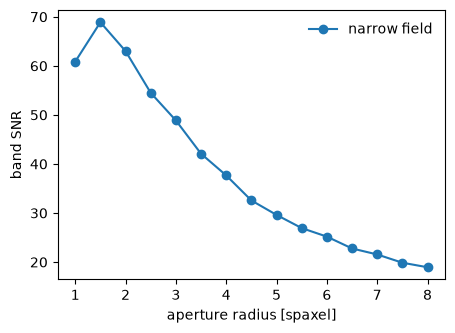

In [5]:
def aperture_snr(target, radii):
    cube_sn, _ = target.get_cube(which="current", switch_off=["background", "thermal"])
    _, varcube = target.get_cube(which="current")
    lbda = target.simulation.spectrograph.lbda
    z = target.get_properties("redshift")
    in_band = (lbda > 4000 * (1 + z)) & (lbda < 7000 * (1 + z))

    signal_img, var_img = cube_sn[in_band].sum(axis=0), varcube[in_band].sum(axis=0)
    iy, ix = np.unravel_index(np.argmax(signal_img), signal_img.shape)
    yy, xx = np.indices(signal_img.shape)
    distance = np.hypot(yy - iy, (xx - ix) / 2)  # in spaxels

    return np.asarray([signal_img[distance <= r].sum() / np.sqrt(var_img[distance <= r].sum())
                       for r in radii])

radii = np.arange(1, 8.5, 0.5)
snr_narrow = aperture_snr(snia, radii)
print(f"optimal radius: {radii[np.argmax(snr_narrow)]} spaxels")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(radii, snr_narrow, "o-", label="narrow field")
ax.set(xlabel="aperture radius [spaxel]", ylabel="band SNR")
ax.legend(frameon=False)

### 5.4 — Narrow or wide field?

Repeat 5.3 in each field, setting it explicitly with `change_spectrograph("narrow")` and
`change_spectrograph("wide")`, with the same detector configuration. Plot the SNR against the aperture radius **in arcsec**
(`get_properties("spatial_scale")` gives the spaxel size). Then compare the SNR reached by
`setup_to_snr(10)` (optimal extraction) in each field. Which field is better for this faint,
high-redshift SN, and why?

narrow: {'nmd': (64, 8, 0), 'nramps': 2}, SNR=9.5, 0.80 h


wide: {'nmd': (64, 8, 0), 'nramps': 2}, SNR=10.7, 0.80 h


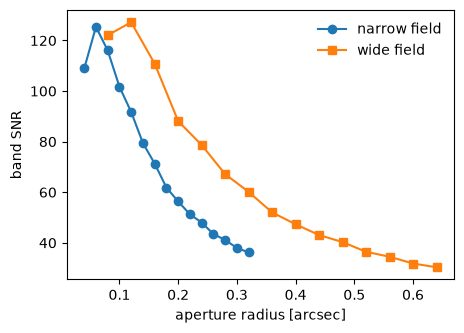

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
for field, marker in [("narrow", "o"), ("wide", "s")]:
    snia.change_spectrograph(field)
    spaxel_scale = snia.get_properties("spatial_scale")  # [arcsec]
    ax.plot(radii * spaxel_scale, aperture_snr(snia, radii), marker + "-", label=f"{field} field")
ax.set(xlabel="aperture radius [arcsec]", ylabel="band SNR")
ax.legend(frameon=False)

for field in ["narrow", "wide"]:
    snia.change_spectrograph(field)
    config, reached = snia.setup_to_snr(10, **snr_range)
    print(f"{field}: {config}, SNR={reached:.1f}, {snia.get_exposure_time()/3600:.2f} h")
snia.change_spectrograph("narrow")
# A simple aperture gives a similar best SNR in both fields. With the optimal (PSF-weighted)
# extraction, the wide field does better: the SN light falls on 4x fewer pixels, so less
# detector noise for the same signal. The narrow field is for well-resolved scenes (hosts).

### 5.5 — Where does the SN land on the detector?

In the narrow field:
1. find the slices (id 1–58) receiving at least 5% of the SN flux. Slice id = 58 − cube row;
2. for each of them, find the detector pixel where λ = 12 000 Å falls at the SN position along
   the slice (`mapper.slice_pos_wave_to_xy`; the position along the slice runs from −1 to +1);
3. project the SN-only cube onto the detector and mark these positions.

In [7]:
import pandas
from slicersim.iotools import expand_path
from slicersim.mapper import SlicerMapper

mapper = SlicerMapper.from_data(pandas.read_csv(expand_path("mapping_spotdata.csv"), sep=" "))

slices: [30 29 28 27] 
pixels (x, y):
 [[ 418. 2248.]
 [ 367. 3260.]
 [ 489. 3254.]
 [ 611. 3249.]]


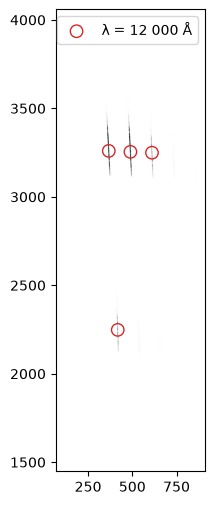

In [8]:
_ = snia.setup_to_snr(10, **snr_range)
cube_sn, _ = snia.get_cube(which="current", switch_off=["background", "thermal"])
lbda = snia.simulation.spectrograph.lbda
nslices, npix = cube_sn.shape[1:]

flux_per_row = cube_sn.sum(axis=(0, 2))
rows = np.nonzero(flux_per_row >= 0.05 * flux_per_row.sum())[0]
sliceids = nslices - rows
ix = np.argmax(cube_sn.sum(axis=(0, 1)))
fieldpos = -1 + 2 * (ix + 0.5) / npix

xy = mapper.slice_pos_wave_to_xy(sliceid=sliceids, fieldpos=np.full(len(sliceids), fieldpos),
                                 lbda=np.full(len(sliceids), 12_000.))
print("slices:", sliceids, "\npixels (x, y):\n", np.round(xy.T))

image_sn = mapper.project_lazulicube(cube_sn, "narrow", lbda)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_sn, origin="lower", cmap="Greys", vmax=np.nanpercentile(image_sn[image_sn > 0], 99))
ax.scatter(*xy, facecolor="none", edgecolor="C3", s=80, label="λ = 12 000 Å")
ax.set(xlim=(xy[0].min() - 300, xy[0].max() + 300), ylim=(xy[1].min() - 800, xy[1].max() + 800))
ax.legend()